In [1]:
#%pip install -U numpy matplotlib imageio tifffile pillow ipython scipy scikit-image ipython

In [2]:
from __future__ import annotations
from dataclasses import dataclass
from pathlib import Path
from typing import Tuple
import numpy as np
import matplotlib.pyplot as plt
import imageio.v3 as iio
import tifffile as tiff
from PIL import Image
from IPython.display import display
from scipy.ndimage import gaussian_filter
from scipy import ndimage as ndi
from skimage.morphology import remove_small_objects, disk, opening, closing
from skimage.segmentation import clear_border
from typing import List, Tuple, Dict, Optional, Iterable




In [3]:
def find_project_root(
    start: str | Path = ".",
    *,
    marker: str = "pictures",
    required_subpath: str = "pictures/pictures_in",
    max_up: int = 10,
) -> Path:
    """
    Find a root directory by walking upwards until `required_subpath` exists.
    """
    p = Path(start).resolve()
    for _ in range(max_up + 1):
        if (p / required_subpath).exists():
            return p
        if p.parent == p:
            break
        p = p.parent
    raise FileNotFoundError(
        f"Cannot find project root from {Path(start).resolve()} "
        f"(missing {required_subpath}). "
        f"Try setting root=Path('...') to your repo root."
    )
def _to_float01(img: np.ndarray) -> np.ndarray: # 将图片数据转换为0-1范围的浮点数
    img = np.asarray(img)
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    if img.ndim == 3 and img.shape[-1] == 4:
        img = img[..., :3]
    if img.ndim != 3 or img.shape[-1] != 3:
        raise ValueError(f"Expect RGB image, got {img.shape}")

    if np.issubdtype(img.dtype, np.floating): # 如果已经是浮点数类型，检查是否需要缩放
        x = img.astype(np.float32, copy=False)
        if np.nanmax(x) > 1.0:
            x = x / 255.0
    else:
        x = img.astype(np.float32) / 255.0
    return np.clip(x, 0.0, 1.0)




def slider_c(val: float) -> float:
    """val in [-100,100] -> c in [-1,1]"""
    return float(np.clip(val, -100, 100) / 100.0)

def slider_factor(val: float) -> float:
    """val in [-100,100] -> factor in [0,2]"""
    c = slider_c(val)
    return float(np.clip(1.0 + c, 0.0, 2.0))
def rgb_to_luma(img01: np.ndarray) -> np.ndarray:
    return (0.2126 * img01[..., 0] +
            0.7152 * img01[..., 1] +
            0.0722 * img01[..., 2])

def adjust_clarity_luma(img01: np.ndarray, clarity: float, sigma: float = 2.0) -> np.ndarray:
    c = slider_c(clarity)  # [-1,1]
    L = rgb_to_luma(img01)                      # (H,W)
    L_blur = gaussian_filter(L, sigma=sigma)    # (H,W)
    L2 = np.clip(L + c * (L - L_blur), 0.0, 1.0)
    eps = 1e-6
    ratio = (L2 + eps) / (L + eps)              # (H,W)
    out = img01 * ratio[..., None]
    return np.clip(out, 0.0, 1.0)

def adjust_brightness(img01: np.ndarray, brightness: float) -> np.ndarray:
    f = slider_factor(brightness)
    return np.clip(img01 * f, 0.0, 1.0)
def adjust_highlights(img01: np.ndarray, highlights: float) -> np.ndarray:
    f = slider_factor(highlights)
    out = img01 + (1.0 - img01) * (f - 1.0)
    return np.clip(out, 0.0, 1.0)

def adjust_contrast(img01: np.ndarray, contrast: float) -> np.ndarray:
    f = slider_factor(contrast)
    return np.clip((img01 - 0.5) * f + 0.5, 0.0, 1.0)

def adjust_saturation(img01: np.ndarray, saturation: float) -> np.ndarray:
    f = slider_factor(saturation)
    luma = (0.2126 * img01[..., 0] + 0.7152 * img01[..., 1] + 0.0722 * img01[..., 2])[..., None]
    out = luma + (img01 - luma) * f
    return np.clip(out, 0.0, 1.0)

def adjust_warmth(img01: np.ndarray, warmth: float) -> np.ndarray:
    c = slider_c(warmth)
    r_factor = float(np.clip(1.0 + c, 0.0, 2.0))
    b_factor = float(np.clip(1.0 - c, 0.0, 2.0))

    out = img01.copy()
    out[..., 0] = np.clip(out[..., 0] * r_factor, 0.0, 1.0)  # R
    out[..., 2] = np.clip(out[..., 2] * b_factor, 0.0, 1.0)  # B
    return out

def apply_sliders(img: np.ndarray, clarity=0, brightness=0, contrast=0, saturation=0, highlights=0, warmth=0, debug=False):
    x = _to_float01(img)
    x = adjust_clarity_luma(x, clarity=clarity, sigma=2.0)
    x = adjust_brightness(x, brightness)
    x = adjust_contrast(x, contrast)
    x = adjust_highlights(x, highlights)
    x = adjust_saturation(x, saturation)
    x = adjust_warmth(x, warmth)
    return x

def fill_black_holes(mask: np.ndarray, max_hole_area: int | None = None) -> np.ndarray:
    m = mask.astype(bool)
    filled_all = ndi.binary_fill_holes(m)

    if max_hole_area is None:
        return filled_all

    holes = filled_all & (~m)          # pixels that would be added to foreground
    if not holes.any():
        return m

    lab, n = ndi.label(holes)
    if n == 0:
        return m

    counts = np.bincount(lab.ravel())  # counts[0] is background
    small_ids = np.where(counts <= max_hole_area)[0]
    small_ids = small_ids[small_ids != 0]

    if small_ids.size == 0:
        return m

    small_holes = np.isin(lab, small_ids)
    return m | small_holes

def denoise_mask_conservative(mask_filled: np.ndarray,
                              min_obj_area: int = 12,
                              drop_border: bool = False) -> np.ndarray:
    m = mask_filled.astype(bool)
    
    if drop_border:
        m = clear_border(m)
    m = remove_small_objects(m, min_size=min_obj_area, connectivity=2)
    
    return m.astype(bool)

def find_centroids(
    mask: np.ndarray,
    *,
    labeled: bool = False,
    connectivity: int = 2,
    min_area: int = 1,
    return_labels: bool = False,
) -> List[Tuple[float, float]] | Tuple[List[Tuple[float, float]], np.ndarray]:

    mask = np.asarray(mask)

    if labeled:
        labels_img = mask.astype(np.int32, copy=False)
        if labels_img.ndim != 2:
            raise ValueError("label image must be 2D")
    else:
        if mask.ndim != 2:
            raise ValueError("binary mask must be 2D")
        # treat anything >0 as foreground
        fg = mask > 0
        # connectivity structure
        structure = ndi.generate_binary_structure(rank=2, connectivity=connectivity)
        labels_img, _ = ndi.label(fg, structure=structure)

    if labels_img.max() == 0:
        out = ([], labels_img) if return_labels else []
        return out

    # compute areas per label
    counts = np.bincount(labels_img.ravel())
    # labels are 1..K
    keep = [lab for lab in range(1, len(counts)) if counts[lab] >= int(min_area)]

    if len(keep) == 0:
        out = ([], labels_img) if return_labels else []
        return out

    # center_of_mass returns (cy, cx)
    centroids = ndi.center_of_mass(np.ones_like(labels_img, dtype=np.float32), labels_img, keep)
    centroids = [(float(cy), float(cx)) for (cy, cx) in centroids]

    if return_labels:
        return centroids, labels_img
    return centroids

def centroids_to_image(
    centroids: list[tuple[float, float]],
    shape: tuple[int, int],
    *,
    radius: int = 2,
    value: int = 255,
) -> np.ndarray:

    h, w = shape
    img = np.zeros((h, w), dtype=np.uint8)

    for cy, cx in centroids:
        y = int(round(cy))
        x = int(round(cx))
        if not (0 <= y < h and 0 <= x < w):
            continue

        if radius <= 0:
            img[y, x] = value
            continue

        y0, y1 = max(0, y - radius), min(h, y + radius + 1)
        x0, x1 = max(0, x - radius), min(w, x + radius + 1)
        yy, xx = np.ogrid[y0:y1, x0:x1]
        disk = (yy - y) ** 2 + (xx - x) ** 2 <= radius ** 2
        img[y0:y1, x0:x1][disk] = value

    return img

def centroids_points_image(
    centroids: list[tuple[float, float]],
    shape: tuple[int, int],
    *,
    radius: int = 2,
) -> np.ndarray:

    h, w = shape
    img = np.full((h, w), 255, dtype=np.uint8)

    for cy, cx in centroids:
        y = int(round(cy))
        x = int(round(cx))
        if not (0 <= y < h and 0 <= x < w):
            continue

        if radius <= 0:
            img[y, x] = 0
            continue

        y0, y1 = max(0, y - radius), min(h, y + radius + 1)
        x0, x1 = max(0, x - radius), min(w, x + radius + 1)
        yy, xx = np.ogrid[y0:y1, x0:x1]
        disk = (yy - y) ** 2 + (xx - x) ** 2 <= radius ** 2
        img[y0:y1, x0:x1][disk] = 0

    return img


In [4]:
# Cell 1 — 定义“一键批处理”函数（ipynb 用）

IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}


@dataclass(frozen=True)
class BatchParams:
    # sliders
    clarity: float = 0
    brightness: float = 0
    highlights: float = 0
    contrast: float = 0
    saturation: float = 0
    warmth: float = 0

    # threshold
    T: float = 0.5
    dark_is_fg: bool = True  # True: gray < T; False: gray > T

    # mask cleanup
    max_hole_area: int = 100
    min_obj_area: float = 0.04
    drop_border: bool = True

    # centroids + points
    min_area: int = 20
    point_radius: int = 6


def _iter_images(folder: Path, recursive: bool = False) -> Iterable[Path]:
    it = folder.rglob("*") if recursive else folder.iterdir()
    for p in it:
        if p.is_file() and p.suffix.lower() in IMG_EXTS:
            yield p


def _export_centroids_csv(centroids: list[tuple[float, float]], out_path: Path) -> None:
   out_path.parent.mkdir(parents=True, exist_ok=True)
   with out_path.open("w", newline="", encoding="utf-8") as f:
        w = csv.writer(f)
        w.writerow(["cy", "cx"])
        for cy, cx in centroids:
            w.writerow([float(cy), float(cx)])

def process_one_for_check(
    img_path: str | Path,
    *,
    params: BatchParams,
    save: bool = True, 
    ):

    img_path = Path(img_path)
    img = np.asarray(Image.open(img_path))

    # 1) sliders first (returns float01 RGB)
    out_change_threshold = apply_sliders(
        img,
        clarity=params.clarity,
        brightness=params.brightness,
        highlights=params.highlights,
        contrast=params.contrast,
        saturation=params.saturation,
        warmth=params.warmth,
    )

    # 2) RGB -> gray -> threshold (bool mask)
    gray = (
        0.2126 * out_change_threshold[..., 0]
        + 0.7152 * out_change_threshold[..., 1]
        + 0.0722 * out_change_threshold[..., 2]
    )
    mask = gray < params.T if params.dark_is_fg else gray > params.T

    # 3) fill holes + denoise (bool->bool)
    mask = fill_black_holes(mask, max_hole_area=params.max_hole_area)
    mask = denoise_mask_conservative(
        mask,
        min_obj_area=params.min_obj_area,
        drop_border=params.drop_border,
    )

    # 4) centroids on bool mask
    centroids = find_centroids(mask, min_area=params.min_area)
    points = centroids_points_image(centroids, mask.shape, radius=params.point_radius)

    # 5) bw visualization (uint8)
    bw = (~mask).astype(np.uint8) * 255

    stats = {
        "img": str(img_path),
        "shape": tuple(mask.shape),
        "mask_true": int(mask.sum()),
        "num_centroids": int(len(centroids)),
    }
    return bw, points, centroids, stats, img

def process_folder(
    in_dir: str | Path,
    out_bw_dir: str | Path,
    out_points_dir: str | Path,
    out_csv_dir: str | Path,
    *,
    params: BatchParams = BatchParams(),
    recursive: bool = False,
) -> None:

    in_dir = Path(in_dir)
    out_bw_dir = Path(out_bw_dir)
    out_points_dir = Path(out_points_dir)
    out_csv_dir = Path(out_csv_dir)

    out_bw_dir.mkdir(parents=True, exist_ok=True)
    out_points_dir.mkdir(parents=True, exist_ok=True)
    out_csv_dir.mkdir(parents=True, exist_ok=True)

    imgs = list(_iter_images(in_dir, recursive=recursive))
    if not imgs:
        print(f"No images found in: {in_dir}")
        return

    for p in imgs:
        try:
            img = np.asarray(Image.open(p))

            # 1) sliders (returns float01 RGB)
            out_change_threshold = apply_sliders(
                img,
                clarity=params.clarity,
                brightness=params.brightness,
                highlights=params.highlights,
                contrast=params.contrast,
                saturation=params.saturation,
                warmth=params.warmth,
            )

            # 2) gray + threshold
            gray = (
                0.2126 * out_change_threshold[..., 0]
                + 0.7152 * out_change_threshold[..., 1]
                + 0.0722 * out_change_threshold[..., 2]
            )
            mask = gray < params.T if params.dark_is_fg else gray > params.T  # bool

            # 3) fill holes + denoise (bool in/bool out)
            mask = fill_black_holes(mask, max_hole_area=params.max_hole_area)
            mask = denoise_mask_conservative(
                mask,
                min_obj_area=params.min_obj_area,
                drop_border=params.drop_border,
            )

            # 4) centroids on bool mask
            centroids = find_centroids(mask, min_area=params.min_area)

            # 5) export bw + points + csv
            bw = (~mask).astype(np.uint8) * 255  # white bg, black fg
            points = centroids_points_image(centroids, mask.shape, radius=params.point_radius)

            Image.fromarray(bw, mode="L").save(out_bw_dir / f"{p.stem}_bcst.test1.png")
            Image.fromarray(points, mode="L").save(out_points_dir / f"{p.stem}_centroids.test1.png")
            _export_centroids_csv(centroids, out_csv_dir / f"{p.stem}_centroids.test1.csv")

            print(f"[OK] {p.name}  centroids={len(centroids)}")
        except Exception as e:
            print(f"[FAIL] {p.name}: {e}")

In [ ]:
#test and virtual display and adjest parameters here:

root = find_project_root(".")  
list_img_name = ("235761_1.tif")   #what do you want to check? 
params = BatchParams(
    clarity=30,
    brightness=70,
    highlights=-100,
    contrast=99,
    saturation=-99,
    warmth=0,
    T=0.5,
    dark_is_fg=True,
    max_hole_area=100,
    min_obj_area=0.2,
    drop_border=False,
    min_area=20,
    point_radius=6,
)
#for img_name in list_img_name:
#    bw, points, centroids, stats, img= process_one_for_check(
#        root / "pictures" / "pictures_in" / img_name,
#        params=params,
#        save=True,
#    )
bw, points, centroids, stats, img= process_one_for_check(
    root / "pictures" / "pictures_in" / "235761_1.tif",
        params=params,
        save=True,
    )

display(Image.fromarray(img, mode="RGB"))
display(Image.fromarray(bw, mode="L"))
display(Image.fromarray(points, mode="L"))
    
stats

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\project\\cancer1.0\\pictures\\pictures_in\\2'

In [ ]:


#auto run all images in the folder with the same parameters:
root = find_project_root(".") # 你项目根目录（ipynb所在目录通常就是）

params = BatchParams(
    clarity=30,
    brightness=70,
    highlights=-100,
    contrast=99,
    saturation=-99,
    warmth=0,
    T=0.5,
    dark_is_fg=True,
    max_hole_area=100,
    min_obj_area=0.2,
    drop_border=False,
    min_area=20,
    point_radius=6,
)

process_folder(
    root / "pictures" / "pictures_in",
    root / "pictures" / "pic_blacknwhite",
    root / "pictures" / "pic_centroids",
    root / "pictures" / "centroids_csv",
    params=params,
    recursive=False,
)


C:\Users\qq187\AppData\Local\Temp\ipykernel_33428\2120466128.py:136: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m = remove_small_objects(m, min_size=min_obj_area, connectivity=2)


[FAIL] 296328_1.tif: name 'csv' is not defined
[FAIL] 296335_1.tif: name 'csv' is not defined
[FAIL] 353793_1.tif: name 'csv' is not defined


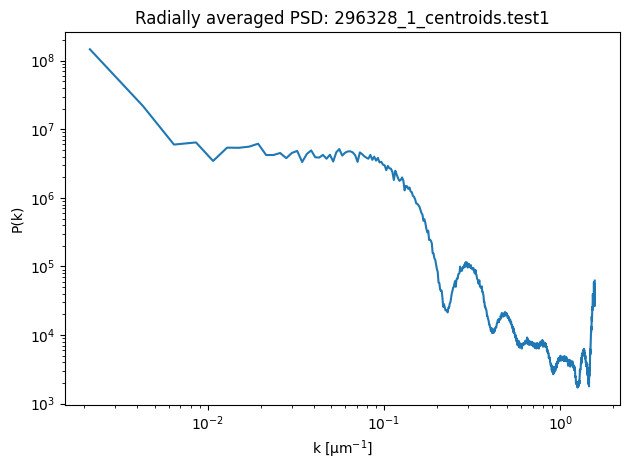

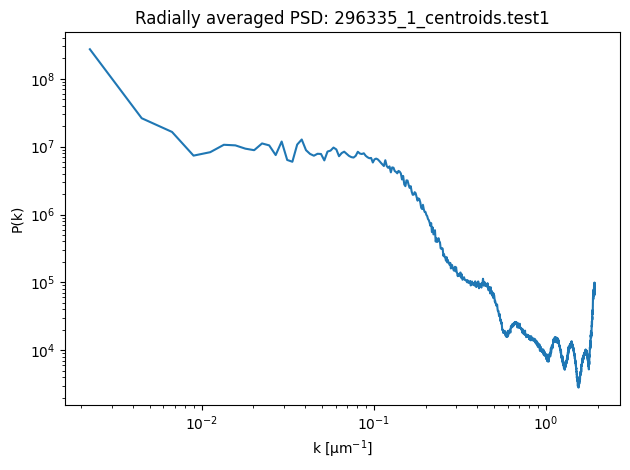

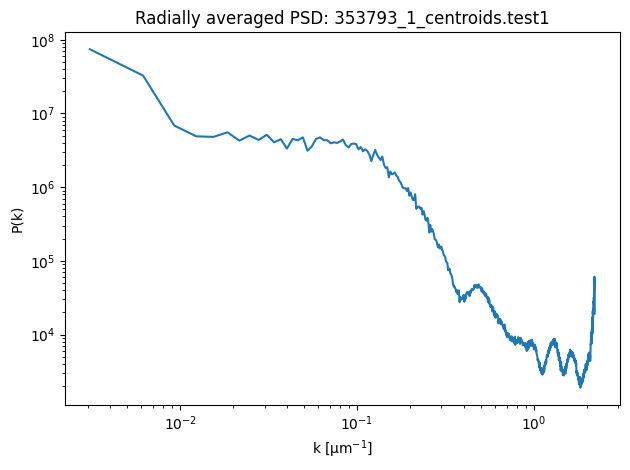

In [ ]:
def psd2d_image(path: str | Path, *, invert_black_points: bool = True) -> np.ndarray:
    """
    Return 2D PSD (float32) computed from centroid point image.
    Assumes centroid image: white bg, black points.
    """
    a = np.asarray(Image.open(path).convert("L"), dtype=np.uint8)
    I = (a < 128).astype(np.float32) if invert_black_points else (a > 128).astype(np.float32)

    f = I - float(I.mean())
    F = np.fft.fft2(f)
    psd = np.abs(F) ** 2
    psd = np.fft.fftshift(psd).astype(np.float32)
    return psd


def radial_psd(psd2d: np.ndarray, pixel_size: float = 1.0):
    """
    Radial average of a 2D PSD (already fftshifted).
    Returns:
      k (µm^-1 if pixel_size in µm/px), Pk
    """
    psd2d = np.asarray(psd2d, dtype=np.float64)
    h, w = psd2d.shape
    cy, cx = h // 2, w // 2

    y, x = np.indices((h, w))
    r = np.sqrt((y - cy) ** 2 + (x - cx) ** 2).astype(np.int32)

    # radial mean
    tbin = np.bincount(r.ravel(), weights=psd2d.ravel())
    nr = np.bincount(r.ravel())
    Pk = tbin / np.maximum(nr, 1)

    # k axis matched to radial bins
    n = float(min(h, w))
    r_bins = np.arange(Pk.size, dtype=np.float64)
    k = r_bins / (n * float(pixel_size))

    return k, Pk

root = find_project_root(".")
in_dir = root / "pictures" / "pic_bw"
out_dir = root / "pictures" / "pic_psd"
out_dir.mkdir(parents=True, exist_ok=True)

pixel_size = 0.5 

for p in sorted(in_dir.glob("*.png")):
    psd2d = psd2d_image(p)
    k, Pk = radial_psd(psd2d, pixel_size=pixel_size)

    # 1) 保存 CSV（k, Pk）
    csv_path = out_dir / "pic_psd_csv" / f"{p.stem}_psd.csv"
    data = np.column_stack([k, Pk])
    np.savetxt(csv_path, data, delimiter=",", header="k_um^-1,Pk", comments="")

    # 2) 保存曲线图 PNG
    fig_path = out_dir / f"{p.stem}_psd.png"
    plt.figure()
    plt.loglog(k[1:], Pk[1:])  # skip k=0
    plt.xlabel("k [µm$^{-1}$]")
    plt.ylabel("P(k)")
    plt.title(f"Radially averaged PSD: {p.stem}")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=200)
    plt.show()
    plt.close()
